In [1]:
# RNN 실습
# - 과거의 sin 값들을 입력받아 다음 시점의 값을 예측

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [9]:
# ================================================
# 1. 시계열 데이터 생성
# ================================================

# 0~100까지 총 1000개의 숫자를 일정한 간격으로 생성
time = np.linspace(0, 100, 1000)

# sin 함수를 사용하여 시계열 데이터 생성
data = np.sin(time)
data

array([ 0.00000000e+00,  9.99330162e-02,  1.98865536e-01,  2.95807081e-01,
        3.89787104e-01,  4.79864709e-01,  5.65138069e-01,  6.44753455e-01,
        7.17913784e-01,  7.83886601e-01,  8.42011406e-01,  8.91706275e-01,
        9.32473678e-01,  9.63905466e-01,  9.85686954e-01,  9.97600074e-01,
        9.99525555e-01,  9.91444120e-01,  9.73436677e-01,  9.45683512e-01,
        9.08462478e-01,  8.62146222e-01,  8.07198446e-01,  7.44169268e-01,
        6.73689717e-01,  5.96465408e-01,  5.13269488e-01,  4.24934884e-01,
        3.32345974e-01,  2.36429728e-01,  1.38146426e-01,  3.84800478e-02,
       -6.15715795e-02, -1.61006773e-01, -2.58830020e-01, -3.54061947e-01,
       -4.45749125e-01, -5.32973611e-01, -6.14862143e-01, -6.90594881e-01,
       -7.59413613e-01, -8.20629350e-01, -8.73629220e-01, -9.17882606e-01,
       -9.52946458e-01, -9.78469728e-01, -9.94196886e-01, -9.99970476e-01,
       -9.95732696e-01, -9.81525973e-01, -9.57492539e-01, -9.23873010e-01,
       -8.81003973e-01, -

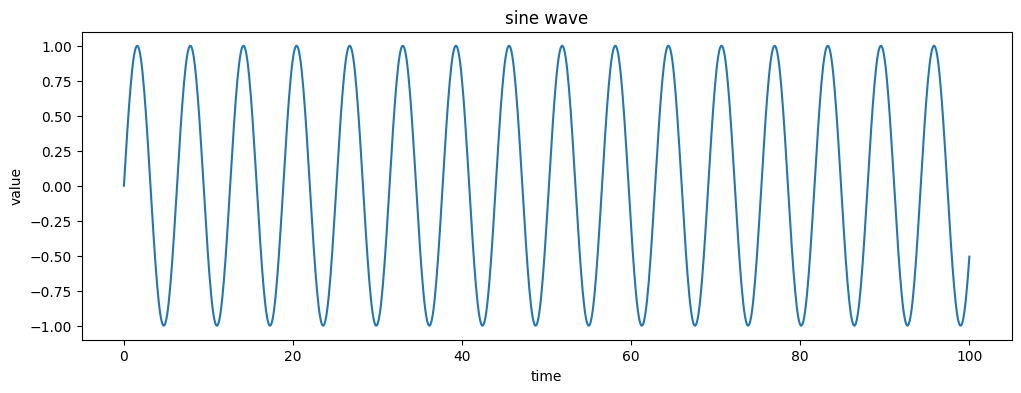

In [10]:
# ================================================
# 2. 데이터 확인
# ================================================
plt.figure(figsize=(12,4))
plt.plot(time, data)
plt.title('sine wave')
plt.xlabel('time')
plt.ylabel('value')
plt.show()

In [11]:
# ================================================
# 3. 학습 데이터 설정
# ================================================

# 최근 20개 데이터를 보고 다음 값을 예측
sequence_length = 20

X = []
y = []

for i in range(len(data) - sequence_length):
    X.append(data[i:i + sequence_length])   # i번째부터 20개 데이터를 입력값으로 사용
    y.append(data[i + sequence_length])     # 입력 데이터 바로 다음값을 정답으로 사용

# 리스트를 numpy 배열로 변환
X = np.array(X)
y = np.array(y)



In [14]:
# ================================================
# 4. RNN 입력 형태로 데이터 변환
# ================================================

print("변환전 x shape : ", X.shape)
# RNN은 기본적으로 3차원 데이터를 입력 받음
'''
- samples : 전체 학스 데이터 개수
- timesteps : 한번에 보는 시간 구간
- features : 각 시점에서 사용하는 특성 개수  <- 각 시간마다 sin값 하나만 사용되기때문에 features = 1
'''

X = X.reshape(
    X.shape[0],   # 전체 데이터 개수
    X.shape[1],   # SEQUENCE 길수 = 20
    1)            # feature 개수 = 1     

print("변환후 x shape : ", X.shape)
print("y shape : ", y.shape)

변환전 x shape :  (980, 20)
변환후 x shape :  (980, 20, 1)
y shape :  (980,)


In [16]:
# ================================================
# 5. 학습/테스트 데이터 분할
# ================================================
split = int(len(X) * 0.8)  # 80% 기준
X_train = X[:split]    # 앞쪽 80%를 학습데이터로 사용
X_test = X[split:]     # 뒤쪽 20%를 테스트 데이터로 사용

# 정답 데이터도 동일하게 80/20으로 분할
y_train = y[:split]    # 앞쪽 80%를 학습데이터로 사용
y_test = y[split:]     # 뒤쪽 20%를 테스트 데이터로 사용

In [19]:
# ================================================
# 6.  RNN 모델 정의
# ================================================
model = Sequential()  # 순차형 신경망 생성

# RNN 레이어 추가
model.add(
    SimpleRNN(
        units=32,    # rnn 내부의 hidden state 크기를 32로 설정
        input_shape=(sequence_length, 1)  # 각 시간마다 20개의 시간 데이터 들어오고, 시간마다 1개의 feature를 사용
    )
)

# 출력층 추가
model.add(Dense(1))   # 출력 노드의 개수 1개

# 모델 구조 확인
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)             │ (None, 32)                  │           1,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# ================================================
# 7. 모델 컴파일 설정
# ================================================
model.compile(
    optimizer='adam',
    loss='mse'    # 실제값과 예측값의 차이를 제곱
)

In [21]:
# ================================================
# 8. 모델 학습
# ================================================
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1    # 학습 진행 상황 출력
)
    

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.1957 - val_loss: 0.0283
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0138 - val_loss: 0.0050
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0023 - val_loss: 0.0015
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.3924e-04 - val_loss: 4.9243e-04
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.3788e-04 - val_loss: 2.0957e-04
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.7125e-04 - val_loss: 1.2204e-04
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0410e-04 - val_loss: 8.1916e-05
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.3736e-05 - val_loss: 6.4943e-05
Epoch 9/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.2932e-05 - val_loss: 5.9777e-05
Epoch 10/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.2077e-05 - val_loss: 6.2178e-05
Epoch 11/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.7761e-05 - val_loss: 5.5972e-05
Epoch 12/

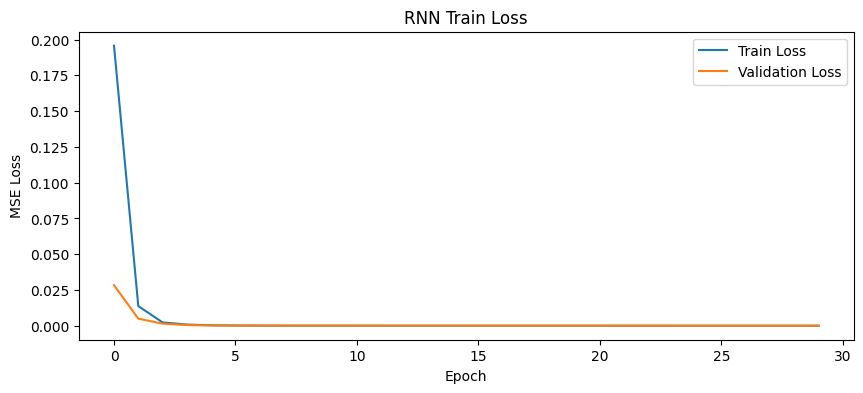

In [22]:
# ================================================
# 9. 학습 시각화
# ================================================
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('RNN Train Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()  # 범례 표시
plt.show()

In [23]:
# ================================================
# 10. 테스트 데이터 예측
# ================================================
y_pred = model.predict(X_test)
y_pred = y_pred.flatten()  # (데이터개수,1) --> 1차원 배열로 변환

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


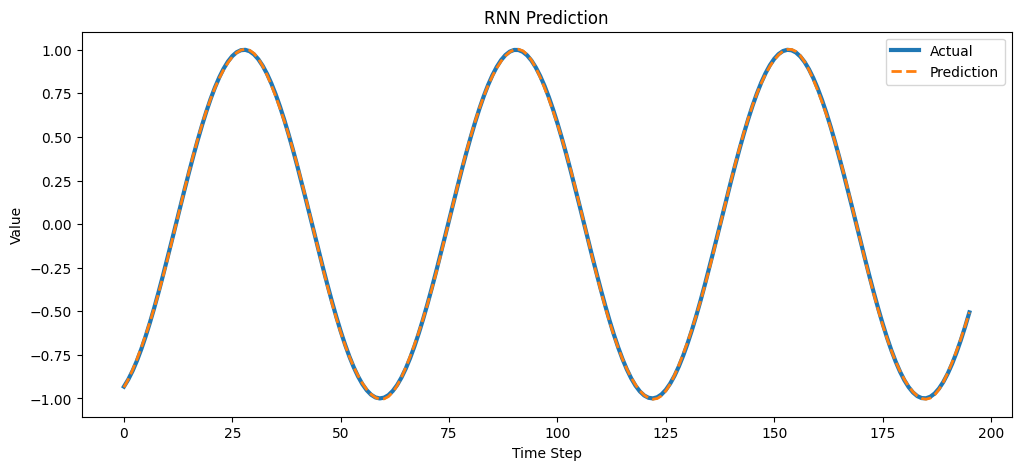

In [24]:
# ================================================
# 11. 실제값과 예측값 비교
# ================================================
plt.figure(figsize=(12,5))
plt.plot(y_test, label='Actual', linewidth=3)
plt.plot(y_pred, label='Prediction',linestyle='--', linewidth=2)

plt.title('RNN Prediction')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()  # 범례 표시
plt.show()

In [25]:
# ================================================
# 12. 미래값 예측
# ================================================

# 앞으로 몇 개의 시점을 예측할 것인지 시점 구간 정의
future_steps = 100

# 미래 예측 결과를 저장할 리스트
future_predictions = []

# sequence lenth = 20를 가져와서 첫번째 미래 값 예측
current_sequence = data[-sequence_length:].copy()

# 지정한 미래 시점만큼 반복 수행
for i in range(future_steps):
    input_sequence = current_sequence.reshape(        # 새로운 입력데이터를 3차원으로 변환  (예측할 데이터, 과거 20개 시점, feature 1개)
        1, sequence_length, 1
    )

    # 현재 20개의 값을 이용해서 다음 시점의 값을 예측
    next_value = model.predict(
        input_sequence,
        verbose=0
    )[0][0]

    # 예측된 값을 미래 예측 리스트에 저장
    future_predictions.append(next_value)

    # 100개으 시점 예측을 위 방식으로 반복하며 하나씩 미래값 예측
    current_sequence = np.append(current_sequence[1:], next_value)

# 리스트를 numpy 배열로 변환
future_predictions = np.array(future_predictions)
    

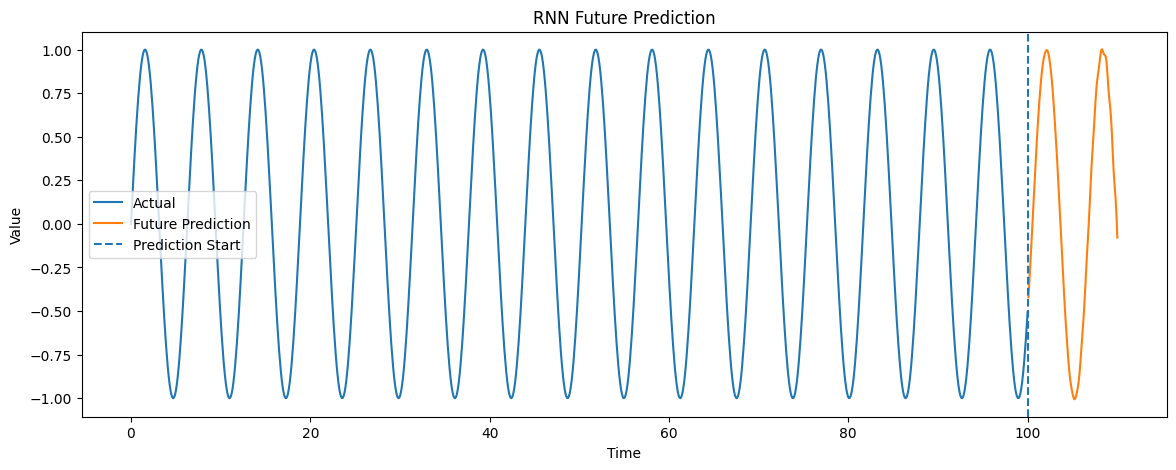

In [27]:
# ================================================
# 13. 결과 시각화
# ================================================

time_step = time[1] - time[0]   # 0.1 간격 설정

# 마지막 시간 이후부터 미래 시간축 생성
future_time = (
    time[-1] + time_step * np.arange(1, future_steps +1))

plt.figure(figsize=(14,5))
plt.plot(time, data, label='Actual')                                    # 기존 실제 sin 데이터 그리기
plt.plot(future_time, future_predictions, label='Future Prediction')    # rnn이 예측한 미래 데이터 출력
        
plt.axvline(x=time[-1], linestyle='--', label='Prediction Start')       # 현재와 미래가 나누어지는 지점 표시

plt.title('RNN Future Prediction')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()   
plt.show()

In [ ]:
)